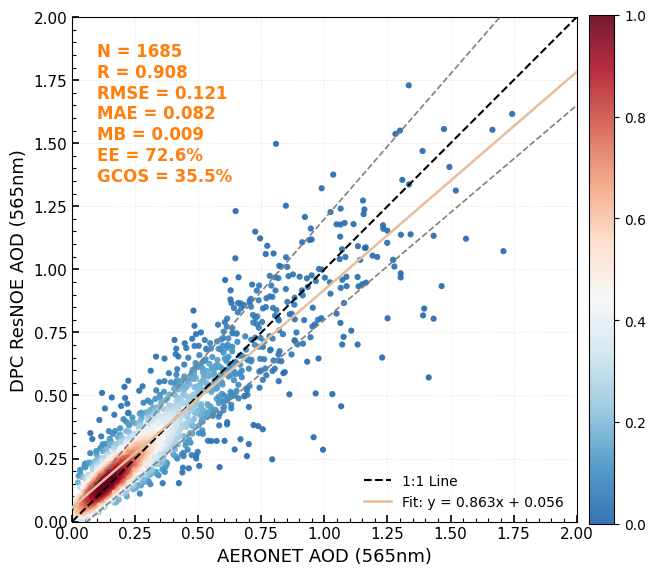

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import gaussian_kde

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# ==================== 辅助函数 ====================
def compute_rmse(y_true, y_pred):
    """计算均方根误差 (RMSE)"""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
    if np.sum(mask) == 0: return np.nan
    mse = np.mean((y_true[mask] - y_pred[mask]) ** 2)
    return np.sqrt(mse)

def compute_r(y_true, y_pred):
    """计算皮尔逊相关系数 (R)"""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
    if np.sum(mask) < 2: return np.nan
    return np.corrcoef(y_true[mask], y_pred[mask])[0, 1]

def compute_mae(y_true, y_pred):
    """计算平均绝对误差 (MAE)"""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
    if np.sum(mask) == 0: return np.nan
    return np.mean(np.abs(y_pred[mask] - y_true[mask]))

def compute_mb(y_true, y_pred):
    """计算平均偏差 (Mean Bias)"""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
    if np.sum(mask) == 0: return np.nan
    return np.mean(y_pred[mask] - y_true[mask])

def compute_ee(y_true, y_pred):
    """计算期望误差 (Expected Error) 内的点的百分比"""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
    if np.sum(mask) == 0: return 0, 0, 0.0
    
    y_true_masked, y_pred_masked = y_true[mask], y_pred[mask]
    
    # GCOS EE: ±(0.05 + 15% * AERONET AOD)
    lower_bound = y_true_masked - (0.15 * y_true_masked) - 0.05
    upper_bound = y_true_masked + (0.15 * y_true_masked) + 0.05
    
    within_ee_mask = (y_pred_masked >= lower_bound) & (y_pred_masked <= upper_bound)
    
    N = len(y_true_masked)
    within_ee_count = np.sum(within_ee_mask)
    ee_percent = (within_ee_count / N) * 100 if N > 0 else 0.0
    
    return N, within_ee_count, ee_percent

def compute_gcos(y_true, y_pred):
    """计算符合 GCOS 标准的点的百分比"""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
    if np.sum(mask) == 0: return 0, 0, 0.0
    
    y_true_masked, y_pred_masked = y_true[mask], y_pred[mask]
    
    # GCOS 阈值：max(0.03, 0.1 * AERONET AOD)
    gcos_threshold = np.maximum(0.03, 0.1 * y_true_masked)
    abs_error = np.abs(y_pred_masked - y_true_masked)
    within_gcos_mask = abs_error <= gcos_threshold
    
    N = len(y_true_masked)
    within_gcos_count = np.sum(within_gcos_mask)
    gcos_percent = (within_gcos_count / N) * 100 if N > 0 else 0.0
    
    return N, within_gcos_count, gcos_percent

# ==================== 数据读取部分 ====================
df = pd.read_csv('/media/amers/SSD_part1/whx/ResNet_forDPC/validation_Final_All.csv')
df = df[df['AOD'] > 0]
df = df[df['AOD_550nm'] > 0]
df = df[df['final_cost'] < 20]
# df = df[~((df['NDVI'] < 0.1) & (df['final_cost'] > 10))]
# df = df[~((df['NDVI'] >= 0.1) & (df['NDVI'] < 0.3) & (df['final_cost'] > 20))]
# df = df[~((df['NDVI'] >= 0.3) & (df['NDVI'] < 0.6) & (df['final_cost'] > 50))]
# df = df[~((df['NDVI'] >= 0.6) & (df['NDVI'] <= 1) & (df['final_cost'] > 60))]

x = df['AOD_550nm'].values  # AERONET AOD
y = df['AOD'].values        # DPC AOD

# ==================== 计算统计指标 ====================
N = len(x)
R = compute_r(x, y)
RMSE = compute_rmse(x, y)
MAE = compute_mae(x, y)
MB = compute_mb(x, y)
_, _, ee_percent = compute_ee(x, y)
_, _, gcos_percent = compute_gcos(x, y)

# ==================== 绘图部分 ====================
fig, ax = plt.subplots(figsize=(7, 7))

# 计算密度用于颜色映射（保持原有配色）
xy = np.vstack([x, y])
z = gaussian_kde(xy)(xy)

# 归一化密度值
z_normalized = (z - z.min()) / (z.max() - z.min())

# 按密度排序，确保高密度点在上方
idx = z_normalized.argsort()
x_sorted, y_sorted, z_sorted = x[idx], y[idx], z_normalized[idx]

# 保持原有的自定义颜色映射（从蓝到红）
colors = ['#2166ac', '#4393c3', '#92c5de', '#d1e5f0', '#f7f7f7', 
          '#fddbc7', '#f4a582', '#d6604d', '#b2182b', '#67001f']
cmap = LinearSegmentedColormap.from_list('custom', colors)

# 绘制密度散点图
scatter = ax.scatter(x_sorted, y_sorted, c=z_sorted, s=20, cmap=cmap, 
                     alpha=0.9, edgecolors='none', zorder=2)

# ==================== 新增：绘制参考线和拟合线 ====================
grid_min, grid_max = 0, 2
line_x = np.linspace(grid_min, grid_max, 100)

# 1:1 线（黑色虚线）
ax.plot(line_x, line_x, color='black', lw=1.5, ls='--', zorder=3, label='1:1 Line')

# GCOS EE 误差线（灰色虚线）
ax.plot(line_x, line_x - (0.15 * line_x + 0.05), color='gray', lw=1.2, ls='--', zorder=3)
ax.plot(line_x, line_x + (0.15 * line_x + 0.05), color='gray', lw=1.2, ls='--', zorder=3)

# 线性拟合线（使用低饱和度橙色，与原配色协调）
parameter = np.polyfit(x, y, 1)
k, b = parameter[0], parameter[1]
p = np.poly1d(parameter)
fit_label = f'Fit: y = {k:.3f}x + {b:.3f}'
ax.plot(line_x, p(line_x), color='#e5bf99', lw=1.8, ls='-', zorder=3, label=fit_label)

# ==================== 统计信息文本（左上角，保持原橙色）====================
stats_text = (
    f'N = {N}\n'
    f'R = {R:.3f}\n'
    f'RMSE = {RMSE:.3f}\n'
    f'MAE = {MAE:.3f}\n'
    f'MB = {MB:.3f}\n'
    f'EE = {ee_percent:.1f}%\n'
    f'GCOS = {gcos_percent:.1f}%'
)
ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, fontsize=12,
        verticalalignment='top', color='#ff7f0e', fontweight='bold')

# ==================== 设置坐标轴 ====================
ax.set_xlim(grid_min, grid_max)
ax.set_ylim(grid_min, grid_max)
ax.set_xlabel('AERONET AOD (565nm)', fontsize=13)
ax.set_ylabel('DPC ResNOE AOD (565nm)', fontsize=13)

# 设置刻度样式（增加刻度线向内）
ax.tick_params(axis='both', which='major', labelsize=11, direction='in', width=1.2, length=5)
ax.tick_params(axis='both', which='minor', direction='in', width=0.8, length=3)
ax.minorticks_on()

# 设置等比例
ax.set_aspect('equal')

# 添加网格线（浅灰色，半透明）
ax.grid(True, linestyle='--', alpha=0.25, linewidth=0.5)

# ==================== 添加图例 ====================
ax.legend(loc='lower right', frameon=False, fontsize=10)

# ==================== 添加颜色条 ====================
cbar = plt.colorbar(scatter, ax=ax, pad=0.02, shrink=0.76)
cbar.ax.tick_params(labelsize=10)

plt.tight_layout()
plt.savefig('/media/amers/SSD_part1/whx/ResNet_forDPC/validation_plot/AOD_validation_scatter.svg', 
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# 打印统计信息
# print(f'数据点数 N = {N}')
# print(f'相关系数 R = {R:.3f}')
# print(f'RMSE = {RMSE:.3f}')
# print(f'MAE = {MAE:.3f}')
# print(f'平均偏差 MB = {MB:.3f}')
# print(f'EE范围内比例 = {ee_percent:.1f}%')
# print(f'GCOS标准内比例 = {gcos_percent:.1f}%')

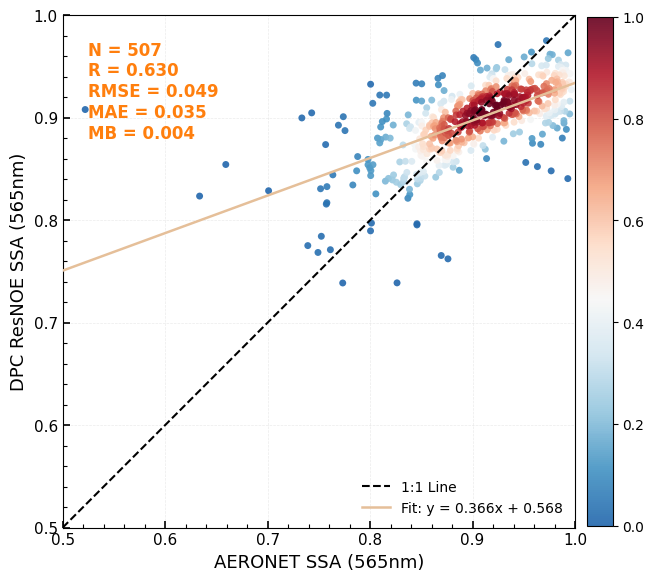

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import gaussian_kde

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# ==================== 辅助函数 ====================
def calculate_ssa_stats(y_true, y_pred):
    """
    计算SSA相关的统计指标
    """
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
    
    if np.sum(mask) < 2:
        return {}
    
    y_true, y_pred = y_true[mask], y_pred[mask]
    
    stats = {}
    stats['N'] = len(y_true)
    stats['R'] = np.corrcoef(y_true, y_pred)[0, 1]
    stats['RMSE'] = np.sqrt(np.mean((y_true - y_pred) ** 2))
    stats['MAE'] = np.mean(np.abs(y_true - y_pred))
    stats['MB'] = np.mean(y_true - y_pred)
    
    # SSA的期望误差范围 (±0.03 或 ±0.05，这里使用±0.05)
    ee_lower = y_true - 0.05
    ee_upper = y_true + 0.05
    
    within_ee_mask = (y_pred >= ee_lower) & (y_pred <= ee_upper)
    stats['EE_percent'] = (np.sum(within_ee_mask) / len(y_true)) * 100
    
    return stats

# ==================== 数据读取部分 ====================
df = pd.read_csv('/media/amers/SSD_part1/whx/ResNet_forDPC/validation_Final_All.csv')

# 数据筛选
df = df[df['AOD'] > 0]
df = df[df['AOD_550nm'] > 0]
df = df[df['SSA'] > 0.5]
df = df[df['SSA_550nm'] > 0.5]
df = df[df['final_cost'] < 15]

# # NDVI筛选
# df = df[~((df['NDVI'] < 0.1) & (df['final_cost'] > 5))]
# df = df[~((df['NDVI'] >= 0.1) & (df['NDVI'] < 0.3) & (df['final_cost'] > 10))]
# df = df[~((df['NDVI'] >= 0.3) & (df['NDVI'] < 0.6) & (df['final_cost'] > 15))]
# df = df[~((df['NDVI'] >= 0.6) & (df['NDVI'] <= 1) & (df['final_cost'] > 20))]

x = df['SSA_550nm'].values  # AERONET SSA
y = df['SSA'].values         # ResNOE SSA

# ==================== 计算统计指标 ====================
stats_dict = calculate_ssa_stats(x, y)
N = stats_dict['N']
R = stats_dict['R']
RMSE = stats_dict['RMSE']
MAE = stats_dict['MAE']
MB = stats_dict['MB']
EE_percent = stats_dict['EE_percent']

# ==================== 绘图部分 ====================
fig, ax = plt.subplots(figsize=(7, 7))

# 计算密度用于颜色映射（保持原有配色）
xy = np.vstack([x, y])
z = gaussian_kde(xy)(xy)

# 归一化密度值
z_normalized = (z - z.min()) / (z.max() - z.min())

# 按密度排序，确保高密度点在上方
idx = z_normalized.argsort()
x_sorted, y_sorted, z_sorted = x[idx], y[idx], z_normalized[idx]

# 保持原有的自定义颜色映射（从蓝到红）
colors = ['#2166ac', '#4393c3', '#92c5de', '#d1e5f0', '#f7f7f7', 
          '#fddbc7', '#f4a582', '#d6604d', '#b2182b', '#67001f']
cmap = LinearSegmentedColormap.from_list('custom', colors)

# 绘制密度散点图
scatter = ax.scatter(x_sorted, y_sorted, c=z_sorted, s=25, cmap=cmap, 
                     alpha=0.9, edgecolors='none', zorder=2)

# ==================== 绘制参考线和拟合线 ====================
grid_min, grid_max = 0.5, 1.0
line_x = np.linspace(grid_min, grid_max, 100)

# 1:1 线（黑色虚线）
ax.plot(line_x, line_x, color='black', lw=1.5, ls='--', zorder=3, label='1:1 Line')

# # SSA期望误差线（灰色虚线，±0.05）
# ax.plot(line_x, line_x - 0.05, color='gray', lw=1.2, ls='--', zorder=3)
# ax.plot(line_x, line_x + 0.05, color='gray', lw=1.2, ls='--', zorder=3)

# 线性拟合线（使用低饱和度橙色，与原配色协调）
parameter = np.polyfit(x, y, 1)
k, b = parameter[0], parameter[1]
p = np.poly1d(parameter)
fit_label = f'Fit: y = {k:.3f}x + {b:.3f}'
ax.plot(line_x, p(line_x), color='#e5bf99', lw=1.8, ls='-', zorder=3, label=fit_label)

# ==================== 统计信息文本（左上角，保持原橙色）====================
stats_text = (
    f'N = {N}\n'
    f'R = {R:.3f}\n'
    f'RMSE = {RMSE:.3f}\n'
    f'MAE = {MAE:.3f}\n'
    f'MB = {MB:.3f}\n'
)
ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, fontsize=12,
        verticalalignment='top', color='#ff7f0e', fontweight='bold')

# ==================== 设置坐标轴 ====================
ax.set_xlim(grid_min, grid_max)
ax.set_ylim(grid_min, grid_max)
ax.set_xlabel('AERONET SSA (565nm)', fontsize=13)
ax.set_ylabel('DPC ResNOE SSA (565nm)', fontsize=13)

# 设置刻度样式（增加刻度线向内）
ax.tick_params(axis='both', which='major', labelsize=11, direction='in', width=1.2, length=5)
ax.tick_params(axis='both', which='minor', direction='in', width=0.8, length=3)
ax.minorticks_on()

# 设置等比例
ax.set_aspect('equal')

# 添加网格线（浅灰色，半透明）
ax.grid(True, linestyle='--', alpha=0.25, linewidth=0.5)

# ==================== 添加图例 ====================
ax.legend(loc='lower right', frameon=False, fontsize=10)

# ==================== 添加颜色条 ====================
cbar = plt.colorbar(scatter, ax=ax,  pad=0.02, shrink=0.76)
cbar.ax.tick_params(labelsize=10)

plt.tight_layout()
plt.savefig('/media/amers/SSD_part1/whx/ResNet_forDPC/validation_plot/SSA_validation_scatter.svg', 
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()



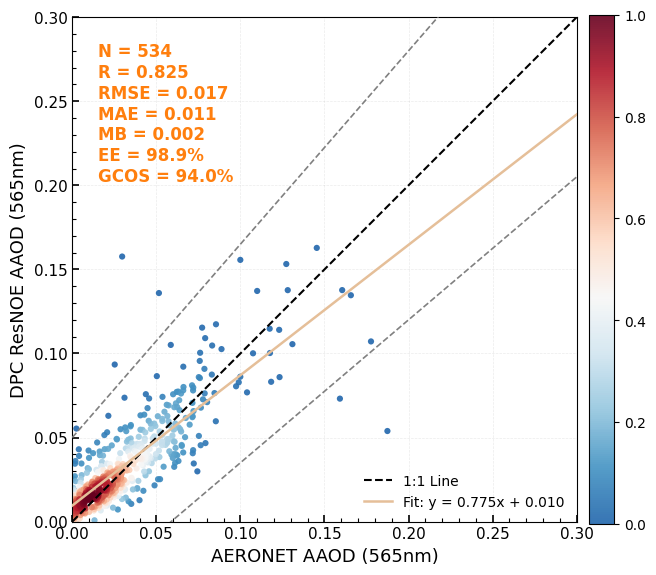

In [ ]:
#AAOD
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import gaussian_kde

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# ==================== 辅助函数 ====================
def compute_rmse(y_true, y_pred):
    """计算均方根误差 (RMSE)"""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
    if np.sum(mask) == 0: return np.nan
    mse = np.mean((y_true[mask] - y_pred[mask]) ** 2)
    return np.sqrt(mse)

def compute_r(y_true, y_pred):
    """计算皮尔逊相关系数 (R)"""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
    if np.sum(mask) < 2: return np.nan
    return np.corrcoef(y_true[mask], y_pred[mask])[0, 1]

def compute_mae(y_true, y_pred):
    """计算平均绝对误差 (MAE)"""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
    if np.sum(mask) == 0: return np.nan
    return np.mean(np.abs(y_pred[mask] - y_true[mask]))

def compute_mb(y_true, y_pred):
    """计算平均偏差 (Mean Bias)"""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
    if np.sum(mask) == 0: return np.nan
    return np.mean(y_pred[mask] - y_true[mask])

def compute_ee(y_true, y_pred):
    """计算期望误差 (Expected Error) 内的点的百分比"""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
    if np.sum(mask) == 0: return 0, 0, 0.0
    
    y_true_masked, y_pred_masked = y_true[mask], y_pred[mask]
    
    # GCOS EE: ±(0.05 + 15% * AERONET AOD)
    lower_bound = y_true_masked - (0.15 * y_true_masked) - 0.05
    upper_bound = y_true_masked + (0.15 * y_true_masked) + 0.05
    
    within_ee_mask = (y_pred_masked >= lower_bound) & (y_pred_masked <= upper_bound)
    
    N = len(y_true_masked)
    within_ee_count = np.sum(within_ee_mask)
    ee_percent = (within_ee_count / N) * 100 if N > 0 else 0.0
    
    return N, within_ee_count, ee_percent

def compute_gcos(y_true, y_pred):
    """计算符合 GCOS 标准的点的百分比"""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
    if np.sum(mask) == 0: return 0, 0, 0.0
    
    y_true_masked, y_pred_masked = y_true[mask], y_pred[mask]
    
    # GCOS 阈值：max(0.03, 0.1 * AERONET AOD)
    gcos_threshold = np.maximum(0.03, 0.1 * y_true_masked)
    abs_error = np.abs(y_pred_masked - y_true_masked)
    within_gcos_mask = abs_error <= gcos_threshold
    
    N = len(y_true_masked)
    within_gcos_count = np.sum(within_gcos_mask)
    gcos_percent = (within_gcos_count / N) * 100 if N > 0 else 0.0
    
    return N, within_gcos_count, gcos_percent

# ==================== 数据读取部分 ====================
df = pd.read_csv('/media/amers/SSD_part1/whx/ResNet_forDPC/validation_Final_All.csv')
df = df[df['AOD'] > 0]
df = df[df['AOD_550nm'] > 0]
df = df[df['final_cost'] < 20]
df = df[df['SSA'] > 0.6]
df = df[df['SSA_550nm'] >0.6]

x = (1-df['SSA_550nm'].values)*df['AOD_550nm'].values
y = (1-df['SSA'].values)*df['AOD'].values

# ==================== 计算统计指标 ====================
N = len(x)
R = compute_r(x, y)
RMSE = compute_rmse(x, y)
MAE = compute_mae(x, y)
MB = compute_mb(x, y)
_, _, ee_percent = compute_ee(x, y)
_, _, gcos_percent = compute_gcos(x, y)

# ==================== 绘图部分 ====================
fig, ax = plt.subplots(figsize=(7, 7))

# 计算密度用于颜色映射（保持原有配色）
xy = np.vstack([x, y])
z = gaussian_kde(xy)(xy)

# 归一化密度值
z_normalized = (z - z.min()) / (z.max() - z.min())

# 按密度排序，确保高密度点在上方
idx = z_normalized.argsort()
x_sorted, y_sorted, z_sorted = x[idx], y[idx], z_normalized[idx]

# 保持原有的自定义颜色映射（从蓝到红）
colors = ['#2166ac', '#4393c3', '#92c5de', '#d1e5f0', '#f7f7f7', 
          '#fddbc7', '#f4a582', '#d6604d', '#b2182b', '#67001f']
cmap = LinearSegmentedColormap.from_list('custom', colors)

# 绘制密度散点图
scatter = ax.scatter(x_sorted, y_sorted, c=z_sorted, s=20, cmap=cmap, 
                     alpha=0.9, edgecolors='none', zorder=2)

# ==================== 新增：绘制参考线和拟合线 ====================
grid_min, grid_max = 0, 0.3
line_x = np.linspace(grid_min, grid_max, 100)

# 1:1 线（黑色虚线）
ax.plot(line_x, line_x, color='black', lw=1.5, ls='--', zorder=3, label='1:1 Line')

# GCOS EE 误差线（灰色虚线）
ax.plot(line_x, line_x - (0.15 * line_x + 0.05), color='gray', lw=1.2, ls='--', zorder=3)
ax.plot(line_x, line_x + (0.15 * line_x + 0.05), color='gray', lw=1.2, ls='--', zorder=3)

# 线性拟合线（使用低饱和度橙色，与原配色协调）
parameter = np.polyfit(x, y, 1)
k, b = parameter[0], parameter[1]
p = np.poly1d(parameter)
fit_label = f'Fit: y = {k:.3f}x + {b:.3f}'
ax.plot(line_x, p(line_x), color='#e5bf99', lw=1.8, ls='-', zorder=3, label=fit_label)

# ==================== 统计信息文本（左上角，保持原橙色）====================
stats_text = (
    f'N = {N}\n'
    f'R = {R:.3f}\n'
    f'RMSE = {RMSE:.3f}\n'
    f'MAE = {MAE:.3f}\n'
    f'MB = {MB:.3f}\n'
    f'EE = {ee_percent:.1f}%\n'
    f'GCOS = {gcos_percent:.1f}%'
)
ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, fontsize=12,
        verticalalignment='top', color='#ff7f0e', fontweight='bold')

# ==================== 设置坐标轴 ====================
ax.set_xlim(grid_min, grid_max)
ax.set_ylim(grid_min, grid_max)
ax.set_xlabel('AERONET AAOD (565nm)', fontsize=13)
ax.set_ylabel('DPC ResNOE AAOD (565nm)', fontsize=13)

# 设置刻度样式（增加刻度线向内）
ax.tick_params(axis='both', which='major', labelsize=11, direction='in', width=1.2, length=5)
ax.tick_params(axis='both', which='minor', direction='in', width=0.8, length=3)
ax.minorticks_on()

# 设置等比例
ax.set_aspect('equal')

# 添加网格线（浅灰色，半透明）
ax.grid(True, linestyle='--', alpha=0.25, linewidth=0.5)

# ==================== 添加图例 ====================
ax.legend(loc='lower right', frameon=False, fontsize=10)

# ==================== 添加颜色条 ====================
cbar = plt.colorbar(scatter, ax=ax, pad=0.02, shrink=0.76)
cbar.ax.tick_params(labelsize=10)

plt.tight_layout()
plt.savefig('/media/amers/SSD_part1/whx/ResNet_forDPC/validation_plot/AAOD_validation_scatter.svg', 
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# 打印统计信息
# print(f'数据点数 N = {N}')
# print(f'相关系数 R = {R:.3f}')
# print(f'RMSE = {RMSE:.3f}')
# print(f'MAE = {MAE:.3f}')
# print(f'平均偏差 MB = {MB:.3f}')
# print(f'EE范围内比例 = {ee_percent:.1f}%')
# print(f'GCOS标准内比例 = {gcos_percent:.1f}%')

In [ ]:
# ==================== 通用绘图函数（目标风格版） ====================
def plot_single_validation(
        df_data,
        col_x,
        col_y,
        xlabel,
        ylabel,
        limits,
        title,
        ee_type='aod'   # 'aod' or 'fmf'
):

    # ==================== 数据预处理 ====================
    temp_df = df_data[[col_x, col_y]].replace([np.inf, -np.inf], np.nan).dropna()

    if len(temp_df) < 5:
        print(f"⚠️ {title} 有效数据点不足")
        return

    x = temp_df[col_x].values
    y = temp_df[col_y].values

    # ==================== 统计指标 ====================
    N = len(x)
    R = np.corrcoef(x, y)[0, 1]
    RMSE = np.sqrt(np.mean((y - x) ** 2))
    MAE = np.mean(np.abs(y - x))
    MB = np.mean(y - x)

    # ==================== EE 计算 ====================
    if ee_type == 'aod':
        lower = x - (0.15 * x + 0.05)
        upper = x + (0.15 * x + 0.05)

    elif ee_type == 'fmf':
        lower = 0.8 * x
        upper = 1.2 * x

    ee_mask = (y >= lower) & (y <= upper)
    ee_percent = np.sum(ee_mask) / N * 100

    # ==================== KDE 密度 ====================
    xy = np.vstack([x, y])

    try:
        z = gaussian_kde(xy)(xy)
    except np.linalg.LinAlgError:
        z = np.ones_like(x)

    # 归一化
    z = (z - z.min()) / (z.max() - z.min())

    # 高密度点放上层
    idx = z.argsort()
    x_sorted = x[idx]
    y_sorted = y[idx]
    z_sorted = z[idx]

    # ==================== colormap ====================
    colors = [
        '#2166ac',
        '#4393c3',
        '#92c5de',
        '#d1e5f0',
        '#f7f7f7',
        '#fddbc7',
        '#f4a582',
        '#d6604d',
        '#b2182b',
        '#67001f'
    ]

    cmap = LinearSegmentedColormap.from_list('custom', colors)

    # ==================== 开始绘图 ====================
    fig, ax = plt.subplots(figsize=(7, 7))

    scatter = ax.scatter(
        x_sorted,
        y_sorted,
        c=z_sorted,
        s=20,
        cmap=cmap,
        alpha=0.9,
        edgecolors='none',
        zorder=2
    )

    # ==================== 参考线 ====================
    line_x = np.linspace(limits[0], limits[1], 200)

    # 1:1 line
    ax.plot(
        line_x,
        line_x,
        color='black',
        lw=1.5,
        ls='--',
        zorder=3,
        label='1:1 Line'
    )

    # ==================== EE误差线 ====================
    if ee_type == 'aod':

        ax.plot(
            line_x,
            line_x - (0.15 * line_x + 0.05),
            color='gray',
            lw=1.2,
            ls='--',
            zorder=3
        )

        ax.plot(
            line_x,
            line_x + (0.15 * line_x + 0.05),
            color='gray',
            lw=1.2,
            ls='--',
            zorder=3
        )

    elif ee_type == 'fmf':

        ax.plot(
            line_x,
            line_x+0.2,
            color='gray',
            lw=1.2,
            ls='--',
            zorder=3
        )

        ax.plot(
            line_x,
            line_x-0.2,
            color='gray',
            lw=1.2,
            ls='--',
            zorder=3
        )

    # ==================== 拟合线 ====================
    parameter = np.polyfit(x, y, 1)

    k = parameter[0]
    b = parameter[1]

    p = np.poly1d(parameter)

    fit_label = f'Fit: y = {k:.3f}x + {b:.3f}'

    ax.plot(
        line_x,
        p(line_x),
        color='#e5bf99',
        lw=1.8,
        ls='-',
        zorder=3,
        label=fit_label
    )

    # ==================== 统计文本 ====================
    stats_text = (
        f'N = {N}\n'
        f'R = {R:.3f}\n'
        f'RMSE = {RMSE:.3f}\n'
        f'MAE = {MAE:.3f}\n'
        f'MB = {MB:.3f}\n'
        f'EE = {ee_percent:.1f}%'
    )

    ax.text(
        0.05,
        0.95,
        stats_text,
        transform=ax.transAxes,
        fontsize=12,
        verticalalignment='top',
        color='#ff7f0e',
        fontweight='bold'
    )

    # ==================== 坐标轴 ====================
    ax.set_xlim(limits[0], limits[1])
    ax.set_ylim(limits[0], limits[1])

    ax.set_xlabel(xlabel, fontsize=13)
    ax.set_ylabel(ylabel, fontsize=13)

    # 刻度
    ax.tick_params(
        axis='both',
        which='major',
        labelsize=11,
        direction='in',
        width=1.2,
        length=5
    )

    ax.tick_params(
        axis='both',
        which='minor',
        direction='in',
        width=0.8,
        length=3
    )

    ax.minorticks_on()

    # 网格
    ax.grid(
        True,
        linestyle='--',
        alpha=0.25,
        linewidth=0.5
    )

    # 等比例
    ax.set_aspect('equal')

    # 图例
    ax.legend(
        loc='lower right',
        frameon=False,
        fontsize=10
    )

    # colorbar
    cbar = plt.colorbar(
        scatter,
        ax=ax,
        pad=0.02,
        shrink=0.76
    )

    cbar.ax.tick_params(labelsize=10)

    plt.tight_layout()

    plt.savefig(f'/media/amers/SSD_part1/whx/ResNet_forDPC/validation_plot/{title}.svg', 
                dpi=300, bbox_inches='tight', facecolor='white')

    plt.show()

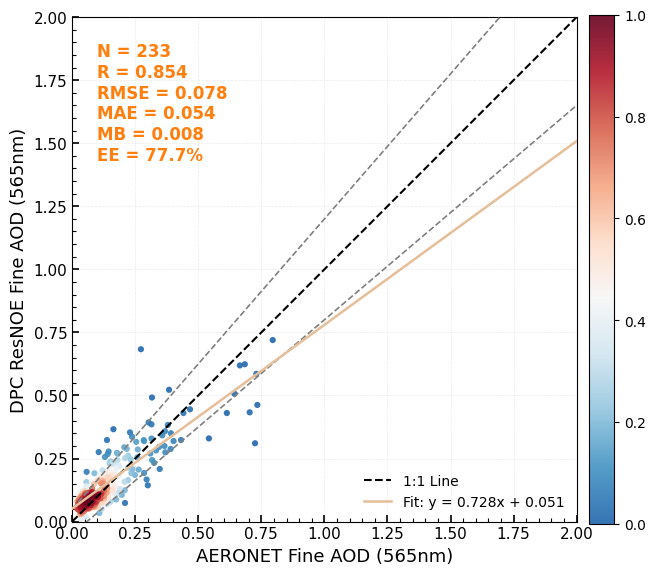

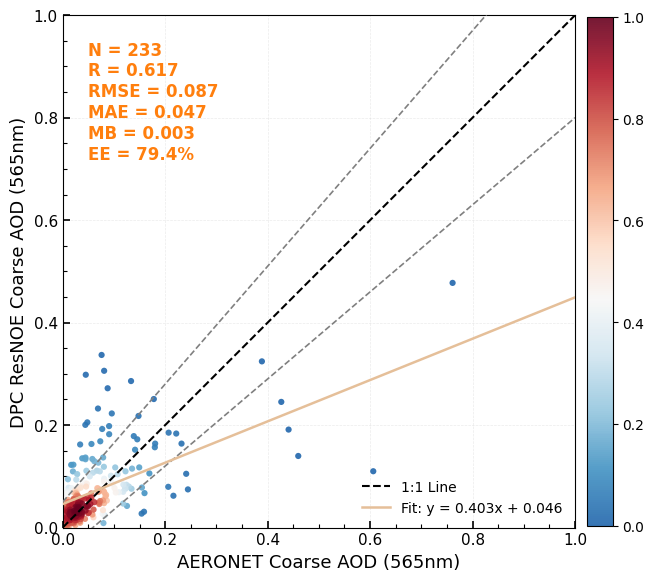

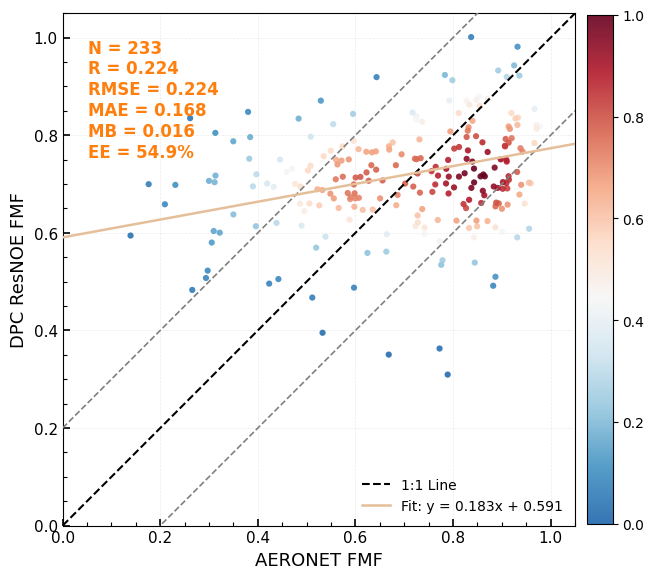

In [ ]:
import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import gaussian_kde
import warnings

CSV_PATH = '/media/amers/SSD_part1/whx/ResNet_forDPC/validation_Final_All.csv'
df = pd.read_csv(CSV_PATH)

# 基础质量控制过滤
df = df[df['final_cost'] < 30]

# 计算 FMF (Fine Mode Fraction)
# 加上 1e-6 防止分母为 0
df['Aeronet_FMF'] = df['Aeronet_FineAOD_565nm'] / (df['Aeronet_FineAOD_565nm'] + df['Aeronet_CoarseAOD_565nm'] )
df['Ret_FMF'] = df['fineAOD'] / (df['fineAOD'] + df['coarseAOD'] )

plot_single_validation(
    df_data=df,
    col_x='Aeronet_FineAOD_565nm',
    col_y='fineAOD',
    xlabel='AERONET Fine AOD (565nm)',
    ylabel='DPC ResNOE Fine AOD (565nm)',
    limits=[0, 2],
    title='Fine Mode AOD Validation',
    ee_type='aod'
)


plot_single_validation(
    df_data=df,
    col_x='Aeronet_CoarseAOD_565nm',
    col_y='coarseAOD',
    xlabel='AERONET Coarse AOD (565nm)',
    ylabel='DPC ResNOE Coarse AOD (565nm)',
    limits=[0, 1],
    title='Coarse Mode AOD Validation',
    ee_type='aod'
)

plot_single_validation(
    df_data=df,
    col_x='Aeronet_FMF',
    col_y='Ret_FMF',
    xlabel='AERONET FMF',
    ylabel='DPC ResNOE FMF',
    limits=[0, 1.05],
    title='Fine Mode Fraction (FMF) Validation',
    ee_type='fmf'
)

(6084, 12138)
(6084, 12138)
(6084, 12138)


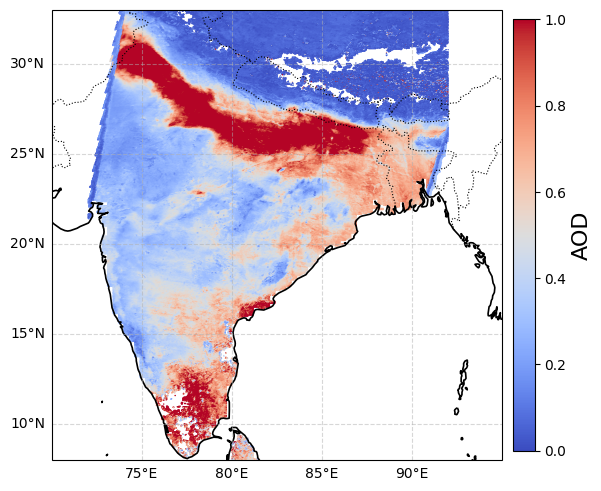

In [39]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature

file_path = '/media/amers/SSD_part1/whx/ResNet_forDPC/GF5B_DPC_20251111_OE.nc'

# ======================
# 1. 读取数据
# ======================
ds = xr.open_dataset(file_path)


# 裁剪掉左右边缘各 15 个像素点
clip_pixels = 15
aod = ds["AOD"].values[:, clip_pixels:-clip_pixels]
lat = ds["latitude"].values[:, clip_pixels:-clip_pixels]
lon = ds["longitude"].values[:, clip_pixels:-clip_pixels]

# ... 然后继续执行你原来的 valid 和 scatter 代码 ...

print(aod.shape)
print(lat.shape)
print(lon.shape)

# ======================
# 2. 构建有效mask
# ======================
valid = (
    np.isfinite(aod) &
    np.isfinite(lat) &
    np.isfinite(lon) &
    (lat >= -90) & (lat <= 90) &
    (lon >= -180) & (lon <= 180)
)

# 无效值全部置 NaN
aod = np.where(valid, aod, np.nan)
lat = np.where(valid, lat, np.nan)
lon = np.where(valid, lon, np.nan)

# ======================
# 3. 创建画布
# ======================
fig = plt.figure(figsize=(7, 7))

ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent([70, 95, 8, 33],
              crs=ccrs.PlateCarree())

# ======================
# 4. 绘图
# ======================
# 有效值mask
valid = (
    np.isfinite(aod) &
    np.isfinite(lat) &
    np.isfinite(lon) &
    (lat >= -90) & (lat <= 90) &
    (lon >= -180) & (lon <= 180)&
    (aod >= 0.001) 
)

im = ax.scatter(
    lon[valid],
    lat[valid],
    c=aod[valid],
    s=1,                 # 点大小
    cmap='coolwarm',
    vmin=0,
    vmax=1,
    linewidths=0,
    transform=ccrs.PlateCarree()
)

# ======================
# 5. 海岸线
# ======================
ax.coastlines(resolution='50m', linewidth=1.2)

ax.add_feature(
    cfeature.BORDERS,
    linestyle=':',
    linewidth=0.8
)

# ======================
# 6. 经纬网
# ======================
gl = ax.gridlines(
    draw_labels=True,
    linestyle='--',
    alpha=0.5
)

gl.top_labels = False
gl.right_labels = False

gl.xlocator = mticker.FixedLocator(np.arange(60, 100, 5))
gl.ylocator = mticker.FixedLocator(np.arange(0, 40, 5))

# ======================
# 7. 色标
# ======================
cbar = plt.colorbar(
    im,
    ax=ax,
    pad=0.02,
    shrink=0.8
)

cbar.set_label("AOD", fontsize=16)

# ======================
# 8. 保存
# ======================
plt.savefig('/media/amers/SSD_part1/whx/ResNet_forDPC/validation_plot/AOD_validation_indian.png', 
            dpi=300, bbox_inches='tight', facecolor='white')

plt.show()

(6084, 12168)
(6084, 12168)
(6084, 12168)


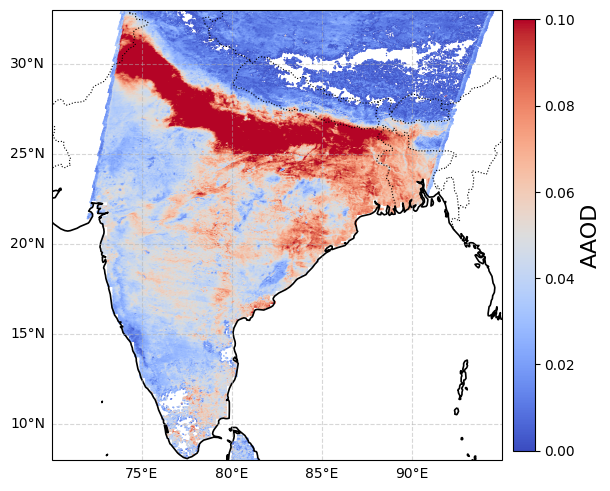

In [40]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature

file_path = '/media/amers/SSD_part1/DPC_project/Inference_GF5B_DPC_Transformer_20251111_finetune.nc'

# ======================
# 1. 读取数据
# ======================
ds = xr.open_dataset(file_path)

ssa = ds["SSA_550nm"].values
aod = (1-ssa)*ds["AOD_550nm"].values
lat = ds["latitude"].values
lon = ds["longitude"].values

print(aod.shape)
print(lat.shape)
print(lon.shape)

# ======================
# 2. 构建有效mask
# ======================
valid = (
    np.isfinite(aod) &
    np.isfinite(lat) &
    np.isfinite(lon) &
    (lat >= -90) & (lat <= 90) &
    (lon >= -180) & (lon <= 180)
)

# 无效值全部置 NaN
aod = np.where(valid, aod, np.nan)
lat = np.where(valid, lat, np.nan)
lon = np.where(valid, lon, np.nan)

# ======================
# 3. 创建画布
# ======================
fig = plt.figure(figsize=(7, 7))

ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent([70, 95, 8, 33],
              crs=ccrs.PlateCarree())

# ======================
# 4. 绘图
# ======================
# 有效值mask
valid = (
    np.isfinite(aod) &
    np.isfinite(lat) &
    np.isfinite(lon) &
    (lat >= -90) & (lat <= 90) &
    (lon >= -180) & (lon <= 180)&
    (aod>=0.001)
)

im = ax.scatter(
    lon[valid],
    lat[valid],
    c=aod[valid],
    s=1,                 # 点大小
    cmap='coolwarm',
    vmin=0,
    vmax=0.1,
    linewidths=0,
    transform=ccrs.PlateCarree()
)

# ======================
# 5. 海岸线
# ======================
ax.coastlines(resolution='50m', linewidth=1.2)

ax.add_feature(
    cfeature.BORDERS,
    linestyle=':',
    linewidth=0.8
)

# ======================
# 6. 经纬网
# ======================
gl = ax.gridlines(
    draw_labels=True,
    linestyle='--',
    alpha=0.5
)

gl.top_labels = False
gl.right_labels = False

gl.xlocator = mticker.FixedLocator(np.arange(60, 100, 5))
gl.ylocator = mticker.FixedLocator(np.arange(0, 40, 5))

# ======================
# 7. 色标
# ======================
cbar = plt.colorbar(
    im,
    ax=ax,
    pad=0.02,
    shrink=0.8
)

cbar.set_label("AAOD", fontsize=16)

# ======================
# 8. 保存
# ======================
plt.savefig('/media/amers/SSD_part1/whx/ResNet_forDPC/validation_plot/AAOD_validation_indian.png', 
            dpi=300, bbox_inches='tight', facecolor='white')

plt.show()

(6084, 12168)
(6084, 12168)
(6084, 12168)


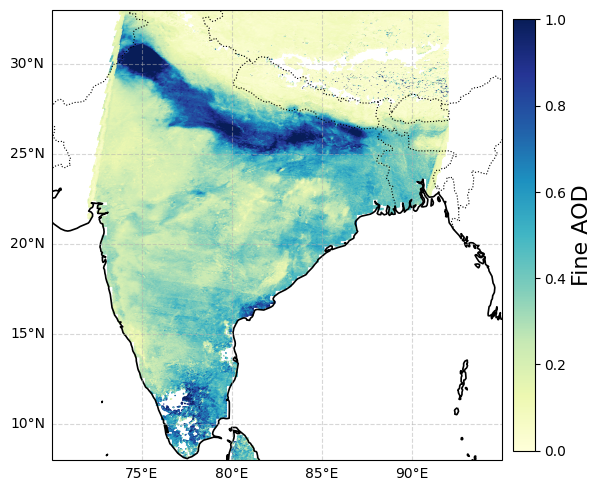

In [41]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature

file_path = '/media/amers/SSD_part1/whx/ResNet_forDPC/GF5B_DPC_20251111_OE.nc'

# ======================
# 1. 读取数据
# ======================
ds = xr.open_dataset(file_path)

aod = ds["fineAOD"].values

lat = ds["latitude"].values
lon = ds["longitude"].values

print(aod.shape)
print(lat.shape)
print(lon.shape)

# ======================
# 2. 构建有效mask
# ======================
valid = (
    np.isfinite(aod) &
    np.isfinite(lat) &
    np.isfinite(lon) &
    (lat >= -90) & (lat <= 90) &
    (lon >= -180) & (lon <= 180)
)

# 无效值全部置 NaN
aod = np.where(valid, aod, np.nan)
lat = np.where(valid, lat, np.nan)
lon = np.where(valid, lon, np.nan)

# ======================
# 3. 创建画布
# ======================
fig = plt.figure(figsize=(7, 7))

ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent([70, 95, 8, 33],
              crs=ccrs.PlateCarree())

# ======================
# 4. 绘图
# ======================
# 有效值mask
valid = (
    np.isfinite(aod) &
    np.isfinite(lat) &
    np.isfinite(lon) &
    (lat >= -90) & (lat <= 90) &
    (lon >= -180) & (lon <= 180)&
    (aod>=0.001)
)

im = ax.scatter(
    lon[valid],
    lat[valid],
    c=aod[valid],
    s=1,                 # 点大小
    cmap='YlGnBu',
    vmin=0,
    vmax=1,
    linewidths=0,
    transform=ccrs.PlateCarree()
)

# ======================
# 5. 海岸线
# ======================
ax.coastlines(resolution='50m', linewidth=1.2)

ax.add_feature(
    cfeature.BORDERS,
    linestyle=':',
    linewidth=0.8
)

# ======================
# 6. 经纬网
# ======================
gl = ax.gridlines(
    draw_labels=True,
    linestyle='--',
    alpha=0.5
)

gl.top_labels = False
gl.right_labels = False

gl.xlocator = mticker.FixedLocator(np.arange(60, 100, 5))
gl.ylocator = mticker.FixedLocator(np.arange(0, 40, 5))

# ======================
# 7. 色标
# ======================
cbar = plt.colorbar(
    im,
    ax=ax,
    pad=0.02,
    shrink=0.8
)

cbar.set_label("Fine AOD", fontsize=16)

# ======================
# 8. 保存
# ======================
plt.savefig('/media/amers/SSD_part1/whx/ResNet_forDPC/validation_plot/Fine_AOD_validation_indian.png', 
            dpi=300, bbox_inches='tight', facecolor='white')

plt.show()

(6084, 12168)
(6084, 12168)
(6084, 12168)


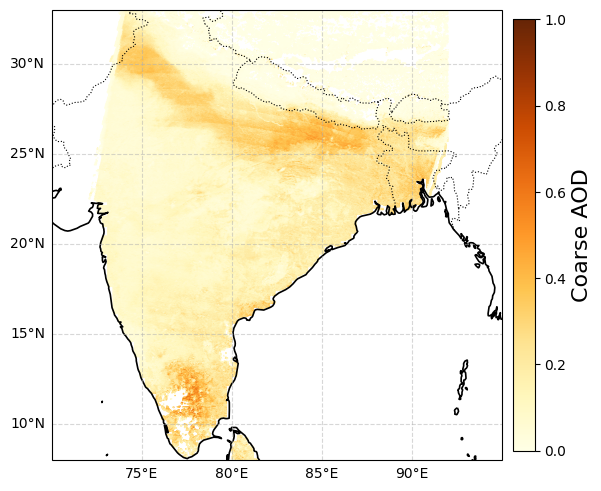

In [ ]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature

file_path = '/media/amers/SSD_part1/whx/ResNet_forDPC/GF5B_DPC_20251111_OE.nc'

# ======================
# 1. 读取数据
# ======================
ds = xr.open_dataset(file_path)

aod = ds["coarseAOD"].values

lat = ds["latitude"].values
lon = ds["longitude"].values

print(aod.shape)
print(lat.shape)
print(lon.shape)

# ======================
# 2. 构建有效mask
# ======================
valid = (
    np.isfinite(aod) &
    np.isfinite(lat) &
    np.isfinite(lon) &
    (lat >= -90) & (lat <= 90) &
    (lon >= -180) & (lon <= 180)
)

# 无效值全部置 NaN
aod = np.where(valid, aod, np.nan)
lat = np.where(valid, lat, np.nan)
lon = np.where(valid, lon, np.nan)

# ======================
# 3. 创建画布
# ======================
fig = plt.figure(figsize=(7, 7))

ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent([70, 95, 8, 33],
              crs=ccrs.PlateCarree())

# ======================
# 4. 绘图
# ======================
# 有效值mask
valid = (
    np.isfinite(aod) &
    np.isfinite(lat) &
    np.isfinite(lon) &
    (lat >= -90) & (lat <= 90) &
    (lon >= -180) & (lon <= 180)&
    (aod>=0.001)
)

im = ax.scatter(
    lon[valid],
    lat[valid],
    c=aod[valid],
    s=1,                 # 点大小
    cmap='YlOrBr',
    vmin=0,
    vmax=1,
    linewidths=0,
    transform=ccrs.PlateCarree()
)

# ======================
# 5. 海岸线
# ======================
ax.coastlines(resolution='50m', linewidth=1.2)

ax.add_feature(
    cfeature.BORDERS,
    linestyle=':',
    linewidth=0.8
)

# ======================
# 6. 经纬网
# ======================
gl = ax.gridlines(
    draw_labels=True,
    linestyle='--',
    alpha=0.5
)

gl.top_labels = False
gl.right_labels = False

gl.xlocator = mticker.FixedLocator(np.arange(60, 100, 5))
gl.ylocator = mticker.FixedLocator(np.arange(0, 40, 5))

# ======================
# 7. 色标
# ======================
cbar = plt.colorbar(
    im,
    ax=ax,
    pad=0.02,
    shrink=0.8
)

cbar.set_label("Coarse AOD", fontsize=16)

# ======================
# 8. 保存
# ======================
# plt.savefig('/media/amers/SSD_part1/whx/ResNet_forDPC/validation_plot/coarseAOD_validation_indian.png', 
#             dpi=300, bbox_inches='tight', facecolor='white')

plt.show()

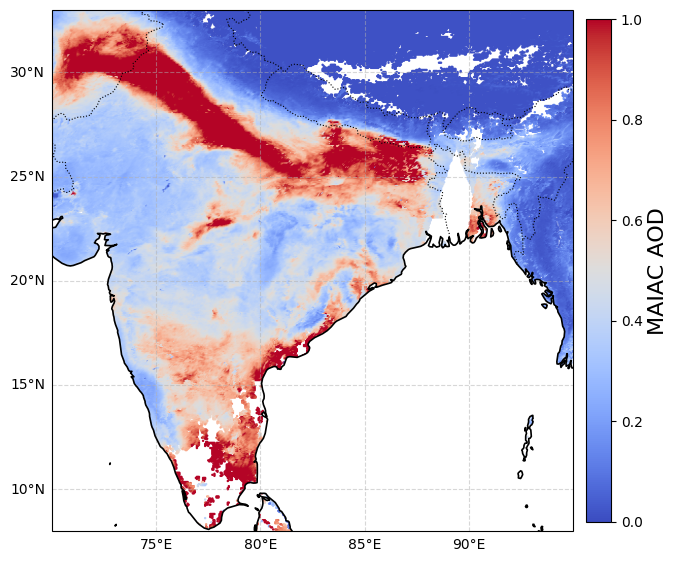

In [43]:
import rioxarray
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# TIFF 文件路径
tif_path = '/media/amers/SSD_part1/whx/ResNet_forDPC/MCD19A2_aod_2025-11-11.tif' 

# ======================
# 1. 读取数据
# ======================
# 使用 rioxarray 读取 TIFF
da = rioxarray.open_rasterio(tif_path)

# 提取 AOD 数据（通常在第1波段）
# 注意：MAIAC TIFF 通常有 scale_factor (通常是 0.001)，读取时会自动应用或需要手动乘
aod_raw = da.values[0].astype(float)

# 处理无效值 (NoData)
nodata = da.rio.nodata
if nodata is not None:
    aod_raw[aod_raw == nodata] = np.nan

# 某些 TIFF 可能没自动应用比例因子，如果数值很大（如 500），请取消下行注释
# aod_raw = aod_raw * 0.001 

# 获取经纬度网格
lon_grid, lat_grid = np.meshgrid(da.x.values, da.y.values)

# ======================
# 2. 构建有效掩膜
# ======================
valid = np.isfinite(aod_raw) & (aod_raw > 0)

# 展平数据用于 scatter 绘制（保持 DPC 风格）
aod_plot = aod_raw[valid]
lon_plot = lon_grid[valid]
lat_plot = lat_grid[valid]

# ======================
# 3. 创建画布
# ======================
fig = plt.figure(figsize=(7, 7))
ax = plt.axes(projection=ccrs.PlateCarree())

# 设置与 DPC 一致的范围
ax.set_extent([70, 95, 8, 33], crs=ccrs.PlateCarree())

# ======================
# 4. 绘图
# ======================
# 仿照 DPC 风格使用 scatter
im = ax.scatter(
    lon_plot,
    lat_plot,
    c=aod_plot,
    s=3,                 
    cmap='coolwarm',
    vmin=0,
    vmax=1.0,            # MAIAC AOD 建议看 0-1.0 范围
    linewidths=0,
    transform=ccrs.PlateCarree(),
    zorder=1             # 确保数据在底层
)

# ======================
# 5. 海陆掩膜与地理特征 (核心：只保留陆地)
# ======================
# 将海洋填充为白色，盖掉可能存在的水上点
ax.add_feature(
    cfeature.OCEAN, 
    facecolor='white', 
    edgecolor='none', 
    zorder=2            # zorder 高于数据点，实现掩膜效果
)

ax.coastlines(resolution='50m', linewidth=1.2, zorder=3)
ax.add_feature(
    cfeature.BORDERS,
    linestyle=':',
    linewidth=0.8,
    zorder=3
)

# ======================
# 6. 经纬网
# ======================
gl = ax.gridlines(
    draw_labels=True,
    linestyle='--',
    alpha=0.5,
    zorder=4
)
gl.top_labels = False
gl.right_labels = False
gl.xlocator = mticker.FixedLocator(np.arange(60, 100, 5))
gl.ylocator = mticker.FixedLocator(np.arange(0, 40, 5))

# ======================
# 7. 色标
# ======================
cbar = plt.colorbar(
    im,
    ax=ax,
    pad=0.02,
    shrink=0.75
)
cbar.set_label("MAIAC AOD", fontsize=16)

plt.tight_layout()
plt.savefig('/media/amers/SSD_part1/whx/ResNet_forDPC/validation_plot/MAIAC_AOD_indian.png', 
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()